<a href="https://colab.research.google.com/github/prabinraics/InsightHunters.io/blob/DAV/Nepal_Housing_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!

First 5 Rows
                                               Title  \
0  Flat System House On Sale At Budhanikantha : H...   
1  21 Aana Beautiful House : House For Sale In Bu...   
2  Beautiful To Floor House : House For Sale In D...   
3  Modern Architecture Bungalow House : House For...   
4  Modern Bungalow House : House For Sale In Golf...   

                                    Address       City      Price  Bedroom  \
0  Budhanikantha, Budhanilkantha, Kathmandu  Kathmandu   90000000        6   
1        Pasikot, Budhanilkantha, Kathmandu  Kathmandu   80000000        5   
2               Dhapasi, Dhapasi, Kathmandu  Kathmandu   70000000        5   
3           baluwatar, Baluwatar, Kathmandu  Kathmandu  130000000        6   
4             Golfutar, Golfutar, Kathmandu  Kathmandu  100000000        6   

   Bathroom  Floors  Parking  Face    Year Views           Area  \
0         3     2.0       10  West  2073.0    17   1-0-0-0 Aana   
1         3     2

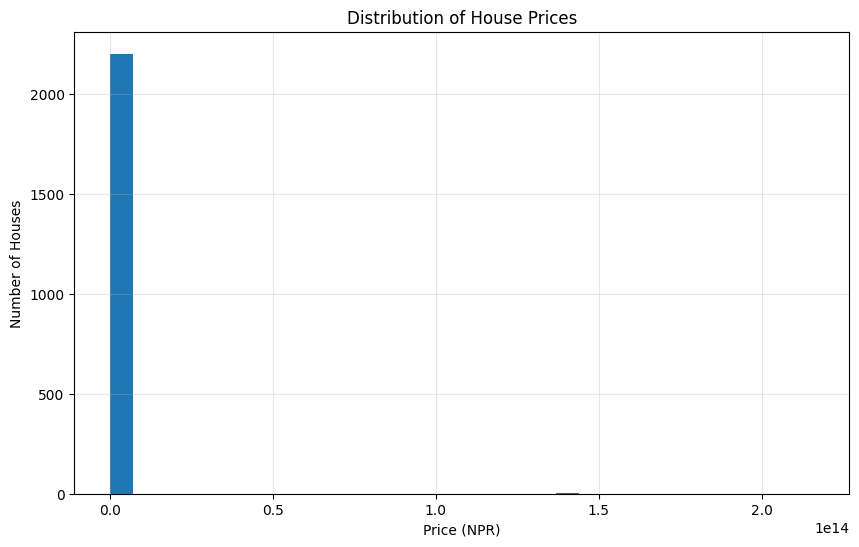

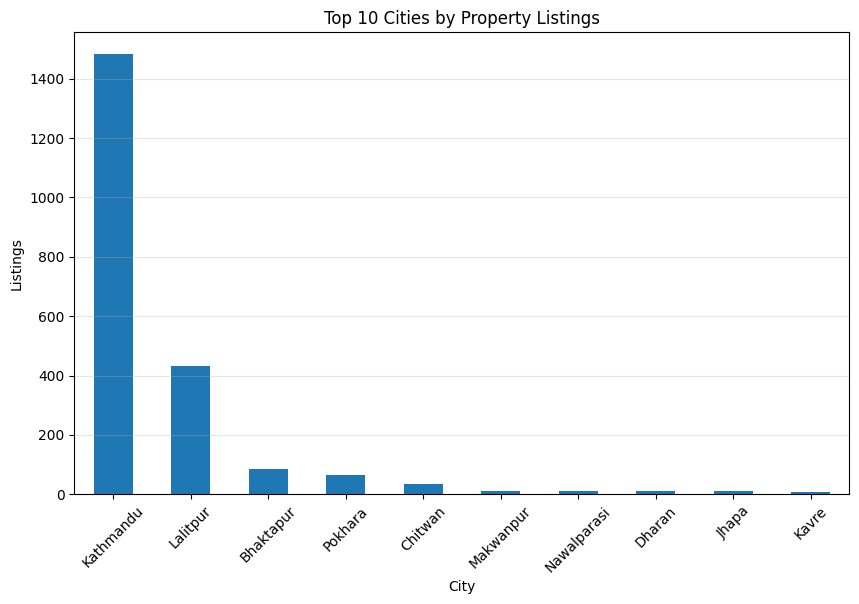

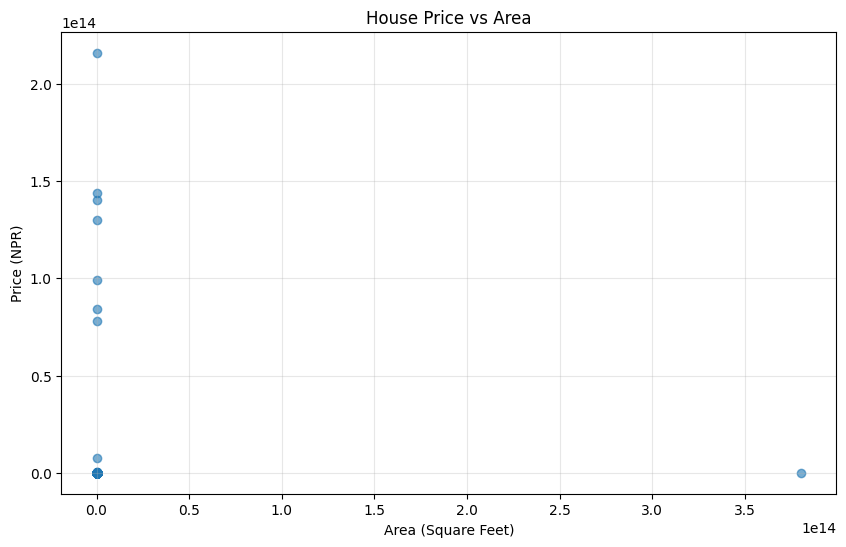


Cleaned dataset saved successfully.

DATA SUMMARY
Total Rows: 2211
Total Columns: 20
Duplicate Rows Removed: 0
Average Price: NPR 406,442,810,870.62
Median Price: NPR 8,000,000.00
Top City: Kathmandu
Price Outliers: 142


In [ ]:
# ==========================================================
# DATA ANALYTICS AND VISUALIZATION SYSTEMS
# Week 1
# Nepal Housing Dataset
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset
df = pd.read_csv("nepalhousing.csv")
print("Dataset Loaded Successfully!")

# Display Dataset
print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print(f"\nTotal Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

print("\nColumn Names")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())


# Check Missing Values
print("\nMissing Values Before Cleaning")
print(df.isnull().sum())


# Check Duplicate Records
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")


# Clean Text Columns
text_columns = [
    "Title",
    "Address",
    "City",
    "Face",
    "Road Type",
    "Amenities"
]

for col in text_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.title()
        )

print("\nText columns cleaned.")


# Clean Price Column
df["Price"] = (
    df["Price"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)


# Clean Area Column
df["Area_Value"] = (
    df["Area"]
    .astype(str)
    .str.extract(r'(\d+\.?\d*)')[0]
    .astype(float)
)


# Convert Area to Square Feet
def convert_to_sqft(area):

    area = str(area).lower()

    try:
        number = float(area.split()[0])
    except:
        return np.nan

    if "anna" in area or "aana" in area:
        return number * 342.25

    elif "ropani" in area:
        return number * 5476

    elif "kattha" in area:
        return number * 3645

    elif "sq" in area:
        return number

    else:
        return np.nan


df["Area_sqft"] = df["Area"].apply(convert_to_sqft)


# Handle Missing Values
numeric_columns = df.select_dtypes(include=["number"]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

object_columns = df.select_dtypes(include=["object"]).columns

for col in object_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning")
print(df.isnull().sum())


# Display Summary Statistics
print("\nSummary Statistics")
print(df.describe())


# Check Unrealistic Prices
print("\nProperties with Price <= 0")
print(df[df["Price"] <= 0])


# Detect Outliers
Q1 = df["Price"].quantile(0.25)
Q3 = df["Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[
    (df["Price"] < Q1 - 1.5 * IQR) |
    (df["Price"] > Q3 + 1.5 * IQR)
]

print(f"\nNumber of Price Outliers: {len(outliers)}")


# Basic Analysis
print("\nAverage House Price")
print(f"NPR {df['Price'].mean():,.2f}")

print("\nMedian House Price")
print(f"NPR {df['Price'].median():,.2f}")

print("\nTop 3 Cities by Listings")
print(df["City"].value_counts().head(3))


# Correlation Analysis
columns = []

for col in ["Price", "Bedroom", "Bathroom", "Parking", "Area_sqft"]:
    if col in df.columns:
        columns.append(col)

print("\nCorrelation Matrix")
print(df[columns].corr())


# Visualization 1 - Price Distribution
plt.figure(figsize=(10,6))
plt.hist(df["Price"], bins=30)
plt.title("Distribution of House Prices")
plt.xlabel("Price (NPR)")
plt.ylabel("Number of Houses")
plt.grid(alpha=0.3)
plt.show()


# Visualization 2 - Top Cities
plt.figure(figsize=(10,6))
df["City"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by Property Listings")
plt.xlabel("City")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Visualization 3 - Price vs Area
plt.figure(figsize=(10,6))
plt.scatter(df["Area_sqft"], df["Price"], alpha=0.6)
plt.title("House Price vs Area")
plt.xlabel("Area (Square Feet)")
plt.ylabel("Price (NPR)")
plt.grid(alpha=0.3)
plt.show()


# Save Cleaned Dataset
df.to_csv("cleaned_nepalhousing.csv", index=False)
print("\nCleaned dataset saved successfully.")

print("\nDATA SUMMARY")

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Duplicate Rows Removed: {duplicates}")
print(f"Average Price: NPR {df['Price'].mean():,.2f}")
print(f"Median Price: NPR {df['Price'].median():,.2f}")
print(f"Top City: {df['City'].value_counts().idxmax()}")
print(f"Price Outliers: {len(outliers)}")

